In [33]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size':14})
import json as js
import os

In [34]:
path = '/home/a/a270230/models/veros/benchmark results/'

In [35]:
lst = os.listdir(path)
files =  [s for s in lst if 'bm_' in s]
files.sort()

In [36]:
[t_n, t_nm, t_j, t_jm, t_jg, t_jgm] = [[] for _ in range(6)]

for file in files:
    
    with open(path+file) as f:
        data = js.load(f)
    
    backend = data['benchmarks']['veris_dyn_benchmark.py'][0]['component']
    time = data['benchmarks']['veris_dyn_benchmark.py'][0]['per_iteration']['mean'],

    if backend=='numpy': t_n += time
    elif backend=='numpy-mpi': t_nm += time
    elif backend=='jax': t_j += time
    elif backend=='jax-mpi': t_jm += time
    elif backend=='jax-gpu': t_jg += time
    elif backend=='jax-gpu-mpi': t_jgm += time 

In [37]:
size = [10**i for i in range(3,8)]

In [38]:
size

[1000, 10000, 100000, 1000000, 10000000]

In [39]:
runtime_mitgcm = np.array([4, 30, 306]) / 100
# n = 256
runtime_mitgcm_mpi = np.array([np.nan, 13, 16, 109, 2660]) / 100

Text(0, 0.5, 'mean time per iteration /s')

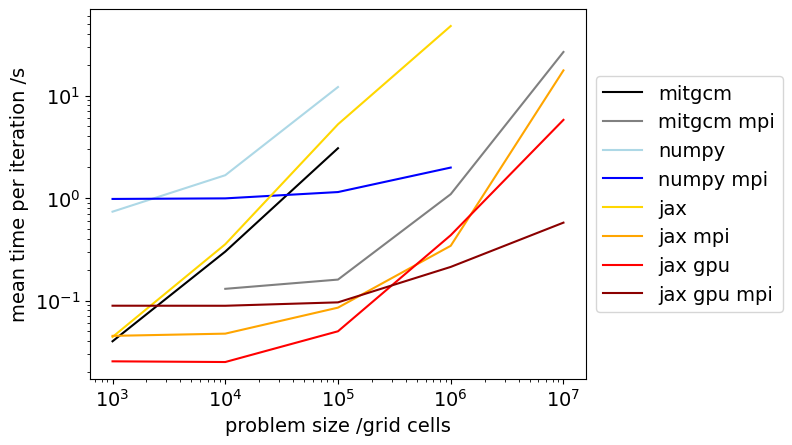

In [40]:
fig = plt.figure()
ax = fig.add_subplot()
for data, label, color in zip([runtime_mitgcm, runtime_mitgcm_mpi, t_n,t_nm,t_j,t_jm,t_jg,t_jgm],
                       ['mitgcm', 'mitgcm mpi', 'numpy','numpy mpi','jax','jax mpi','jax gpu', 'jax gpu mpi'],
                       ['black', 'grey', 'lightblue','blue','gold','orange','red','darkred']):
    ax.plot(size[:len(data)],data,label=label,color=color)

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('problem size /grid cells')
ax.set_ylabel('mean time per iteration /s')